# Piezoelectricity

Squeeze a crystal and a voltage appears across it. The coefficient that says how much is the
piezoelectric tensor: the polarization induced by a strain, at zero field,

$$ e_{k,ij} \;=\; \frac{\partial P_k}{\partial \varepsilon_{ij}}
   \;=\; \frac{\partial \sigma_{ij}}{\partial \mathcal{E}_k}
   \;=\; -\frac{1}{\Omega}\,\frac{\partial^2 E}{\partial \varepsilon_{ij}\,\partial \mathcal{E}_k} $$

The two forms on the left are the same number, because a mixed second derivative does not
care which of its two legs is taken first: the polarization a strain induces is the stress a
field induces. That is Maxwell's relation for the electromechanical coupling, and it is what
makes the quantity cheap here. The second derivative is taken of the energy itself rather
than derived by hand, so the whole tensor costs one extra pass over an electric-field
response that a dielectric constant needs anyway.

Not every crystal has one. A tensor with an odd number of Cartesian labels vanishes
identically in any crystal with an inversion centre, so silicon is not piezoelectric and
AlAs, which is the same structure with the two sublattices made inequivalent, is.

| | this notebook | reference |
|---|---|---|
| AlAs $e_{14}$, clamped-ion | **-0.764 C/m²** at this cell's mesh, **-0.670** at $10^3$ | **-0.661**, a polarization difference |
| silicon, every component | **< 10⁻⁵ C/m²** | zero, by inversion symmetry |
| components $\bar{4}3m$ forbids | 2 × 10⁻¹⁴ of the scale | zero, and nothing imposes it |

**The reference is unusual and worth a sentence.** Quantum ESPRESSO does not compute a
piezoelectric tensor at all, and the one established code that does gets it from a finite
difference of the polarization over a separate self-consistent calculation for every strain.
That is the reference quoted above, and it is worth trusting precisely because it shares no
machinery with what this notebook computes: no response solver, no derivative, just two
converged ground states and the Berry phase of each.

**Read the first row twice, because it is the useful thing in this notebook.** The $-0.764$
is what the cell below prints, on the $4\times4\times4$ k-mesh the input file asks for, and
it is thirteen per cent from the value the finer meshes are walking toward. Going to $6^3$,
$8^3$ and $10^3$ gives $-0.687$, $-0.673$ and $-0.670$, still moving at the last step, while
the polarization difference sits at $-0.661$ throughout and moves by less than one per cent
whatever it is asked to do. So the mesh that converges the
*energy* of this crystal does not converge its piezoelectric constant, and the reason is
visible in the definition at the top: $e_{14}$ is a mixed derivative of an energy that is
already stationary in the density, so the variational protection that makes a total energy
forgiving about the zone sum is simply absent. **Converge the mesh on this quantity, not on
the ground state**, whenever you want a piezoelectric constant to a few per cent. The
calculation says so itself: it reports the sample it integrated and warns that nothing
inside a piezoelectric tensor can see its own zone sum, and
`get_piezoelectric_kmesh_ladder` walks the meshes for a crystal of your own and reports
how much the last step moved.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defumat import Calculator

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

alas = Calculator.from_file(CASES / "alas-raman.in", pseudo_dir=PSEUDO, announce=False)
piezo = alas.get_piezoelectric_tensor()

print(f"AlAs   e_14 = {piezo.e14:+.4f} C/m2      epsilon = {np.trace(piezo.dielectric.epsilon) / 3:.4f}")

/u/40/ladovj1/data/Documents/programs/claude/defumat/defumat/calculator.py:1043: RuntimeWarning: the piezoelectric tensor was integrated over 64 k-points (4 4 4) and this run's own k-convergence has not been measured. On zincblende AlAs, against a Berry-phase finite difference that shares no machinery with it, e_14 reads -0.7638, -0.6875, -0.6729, -0.6699 C/m^2 at 4 4 4, 6 6 6, 8 8 8 and 10 10 10 against the Berry value's -0.6614 to -0.6620, so a committed-quality 4 4 4 mesh is 13 per cent out there and 8 8 8 is 1.6. Nothing inside this quantity can see that: the three routes share one field response and the Z* anchor is the same assembly in the position coordinate, so every internal check moves with the mesh instead of catching it. Measure this crystal's own curve with defumat.workflows.piezo_ladder.piezoelectric_kmesh_ladder (Calculator.get_piezoelectric_kmesh_ladder), which reruns the ground state and the response on a ladder of meshes and puts the last step on the result; pass kmes

AlAs   e_14 = -0.7638 C/m2      epsilon = 12.9674


## 1. One independent component, and nothing else

AlAs is $\bar{4}3m$. In that class a rank-3 tensor symmetric in its two strain labels has
exactly one independent component, $e_{14} = e_{25} = e_{36}$, and every other entry has to
vanish. The run below uses the whole Brillouin-zone grid with no symmetry applied anywhere,
so what appears in the table is what the derivative produced, not what a symmetriser put
there.

The columns are the six independent strains in the usual order, and the rows are the
direction the polarization points along. A shear in the $yz$ plane polarizes the crystal
along $x$: the two sublattices slide past each other and the bond charge follows.

In [2]:
LABELS = ["xx", "yy", "zz", "yz", "xz", "xy"]
allowed = [(0, 3), (1, 4), (2, 5)]

print("e_iJ  [C/m2]      " + "".join(f"{c:>9}" for c in LABELS))
for i, row in zip("xyz", piezo.voigt):
    print(f"  P along {i}       " + "".join(f"{v:9.4f}" for v in row))

forbidden = max(abs(piezo.voigt[i, j]) for i in range(3) for j in range(6)
                if (i, j) not in allowed)
print(f"\nlargest component the crystal class forbids: "
      f"{forbidden / abs(piezo.e14):.1e} of e_14")

e_iJ  [C/m2]             xx       yy       zz       yz       xz       xy
  P along x         -0.0000  -0.0000  -0.0000  -0.7638  -0.0000  -0.0000
  P along y          0.0000  -0.0000   0.0000  -0.0000  -0.7638   0.0000
  P along z          0.0000   0.0000  -0.0000  -0.0000  -0.0000  -0.7638

largest component the crystal class forbids: 2.5e-14 of e_14


## 2. Silicon has none, and that is the point

Diamond and zincblende are the same lattice with the same neighbours. The only difference is
that AlAs puts two different atoms on the two sublattices, which removes the inversion
centre sitting halfway along the bond. That single symmetry element is what decides whether
the crystal is piezoelectric, and nothing else about the two materials does.

In [3]:
silicon = Calculator.from_file(CASES / "si2-nosym.in", pseudo_dir=PSEUDO,
                               announce=False)
si_piezo = silicon.get_piezoelectric_tensor()

print(f"AlAs      largest component  {np.abs(piezo.voigt).max():.4f} C/m2")
print(f"silicon   largest component  {np.abs(si_piezo.voigt).max():.2e} C/m2")

AlAs      largest component  0.7638 C/m2
silicon   largest component  9.78e-06 C/m2


## 3. The two tensors side by side

Same colour scale, same structure, one symmetry element apart.

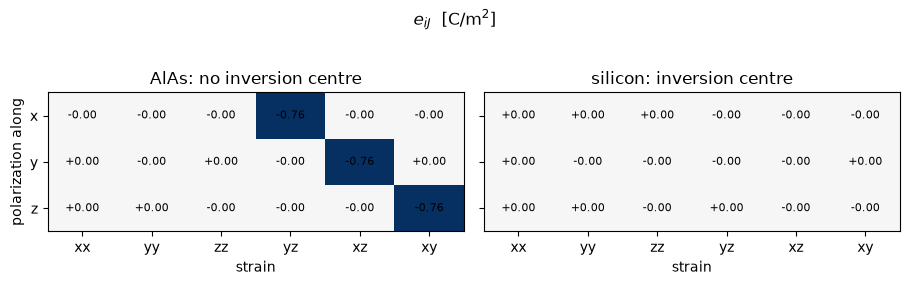

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 2.7), sharey=True)
scale = np.abs(piezo.voigt).max()

for ax, table, name in ((axes[0], piezo.voigt, "AlAs: no inversion centre"),
                        (axes[1], si_piezo.voigt, "silicon: inversion centre")):
    ax.imshow(table, cmap="RdBu_r", vmin=-scale, vmax=scale, aspect="auto")
    for i in range(3):
        for j in range(6):
            ax.text(j, i, f"{table[i, j]:+.2f}", ha="center", va="center", fontsize=8)
    ax.set(xticks=range(6), xticklabels=LABELS, yticks=range(3),
           yticklabels=list("xyz"), title=name, xlabel="strain")

axes[0].set_ylabel("polarization along")
fig.suptitle(r"$e_{iJ}$  [C/m$^2$]", y=1.04)
fig.tight_layout()

## 4. What a laboratory measures, and why this is not yet it

The number above holds the atoms where the strain puts them: every atom moves affinely with
the cell and none of them relaxes afterwards. That is the clamped-ion piezoelectric
constant, and it is the electronic half of the effect.

The other half is that a shear strain leaves a force on the atoms, they relax, and the
displaced ions carry their own dipoles. In the III-V semiconductors those two halves have
opposite signs and are close in size, so the measured constant is a small residue of two
large numbers: linear-response work on this family gives AlAs a total $|e_{14}|$ of order
0.01 C/m², against the 0.76 of the electronic half alone. The cancellation is the physics
here, and it is why a converged calculation matters more for this quantity than for most.

The internal-strain half is not computed in this notebook. Everything it is built from is
available (the effective charges of notebook 19 and the force constants of notebook 20), and
the piece that joins them is the force a strain leaves behind.

## 5. What it refuses

- **Polar crystals.** In a crystal that can carry a spontaneous polarization, what is
  measured differs from the derivative above by terms built from that polarization itself.
  They vanish whenever the two Cartesian labels they pair are different, which is why
  $e_{14}$ of a zincblende crystal is never ambiguous, and they vanish altogether for a
  crystal class that leaves no direction invariant. A class that does leave one invariant is
  refused by name rather than reported with a term missing.
- **Clamped-ion only**, as above.
- **The softest datasets, and a coarse mesh with them.** A softer pseudopotential keeps
  part of the electron density as a compact cloud pinned to each nucleus, and a strain
  carries and deforms that cloud rather than simply moving it, so the strain derivative of
  the energy gains terms the harder datasets do not have. Those terms are in, and the
  comparison that was missing has been made: on the same zincblende crystal an ultrasoft
  $e_{14}$ sits 0.57 per cent from the polarization difference at $10^3$, where the
  norm-conserving calibration is 1.19 per cent from its own at the same mesh. So an
  ultrasoft dataset runs, and only above eight divisions in each direction, since below
  that the dataset and the mesh cannot be told apart. A PAW dataset is still refused by
  name: it has been checked against itself and never against anything outside.
- **Insulators**, and everything else the linear-response solver needs: no metals, no spin
  spiral, no magnetic field, and a shifted k-grid only where the symmetry is kept.

## Tests

`tests/regression/test_piezoelectric.py` holds the validation: the vanishing on silicon, the
crystal class of AlAs, the agreement between a symmetry-reduced set of k-points and the
whole grid, and the three independent routes to the same mixed derivative.
`tests/unit/test_piezo_machinery.py` holds the notation and the symmetry guard.